In [1]:
!pip install visualkeras --quiet

In [2]:
import numpy as np

import pandas as pd

from collections import Counter

from matplotlib import pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Rescaling, Conv2D, MaxPooling2D, Dense, Flatten, Input, Dropout, BatchNormalization
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from keras.regularizers import l2

from keras import callbacks

import visualkeras

import cv2

import os

import PIL

import random

import pathlib

from sklearn.metrics import classification_report

## **Load dataset**

In [3]:
dataset_path = "/kaggle/input/identifying-disease-in-tea-leafs/tea sickness dataset"
dataset_dir = pathlib.Path(dataset_path)

In [4]:
# Get only immediate subdirectories under dataset_path
class_names = next(os.walk(dataset_path))[1]

print(class_names)

['white spot', 'Anthracnose', 'healthy', 'bird eye spot', 'brown blight', 'red leaf spot', 'gray light', 'algal leaf']


In [5]:
# Number of images per class
for class_i in class_names:
    image_count = len(list(dataset_dir.glob(f'{class_i}/*.jpg')))
    print(f"Images in class {class_i}:",image_count)

Images in class white spot: 142
Images in class Anthracnose: 100
Images in class healthy: 74
Images in class bird eye spot: 100
Images in class brown blight: 113
Images in class red leaf spot: 143
Images in class gray light: 100
Images in class algal leaf: 113


In [6]:
# Parameter setting
train_batch = 128
val_batch = 128
img_height = 224
img_width = 224
IMG_SIZE = (img_height, img_width)
val_split = 0.3

In [7]:
train_ds = image_dataset_from_directory(dataset_dir,
                                        validation_split=val_split,
                                        subset="training",
                                        seed=123,
                                        image_size=(img_height, img_width),
                                        batch_size=train_batch
)

Found 885 files belonging to 8 classes.
Using 620 files for training.


In [8]:
type(train_ds)

tensorflow.python.data.ops.dataset_ops.BatchDataset

Each element in $\textit{train\_ds}$ is a $(\text{images}, \text{labels})$ tuple.

$\bullet$ $\textit{images}$ is a tensor of shape $(\text{batch\_size}, \text{image\_height}, \text{image\_width}, \text{channels})$

$\bullet$ $\textit{labels}$ is a tensor of shape $(\text{batch\_size}, \text{num\_classes})$

In [9]:
print(train_ds.class_names)

['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']


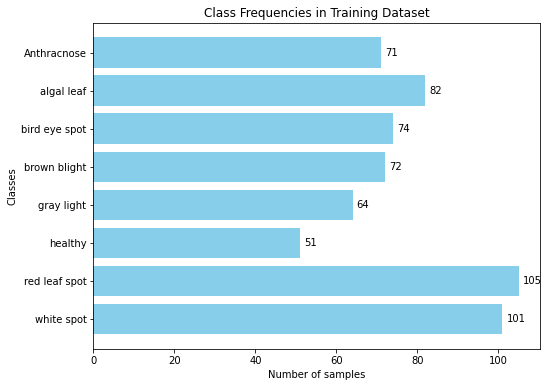

In [10]:
class_names = train_ds.class_names

# Count class frequencies
class_counts = Counter()
for images, labels in train_ds:
    labels = labels.numpy()
    class_counts.update(labels)

counts = [class_counts[i] for i in range(len(class_names))]
labels = class_names

# Create horizontal bar plot
plt.figure(figsize=(8, 6))
bars = plt.barh(labels, counts, color='skyblue')
plt.xlabel("Number of samples")
plt.ylabel("Classes")
plt.title("Class Frequencies in Training Dataset")
plt.gca().invert_yaxis()

# Add counts on the bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(count), va='center')

plt.show()

In [11]:
val_ds = image_dataset_from_directory(dataset_dir,
                                      validation_split=val_split,
                                      subset="validation",
                                      seed=123,
                                      image_size=(img_height, img_width),
                                      batch_size=val_batch
)

Found 885 files belonging to 8 classes.
Using 265 files for validation.


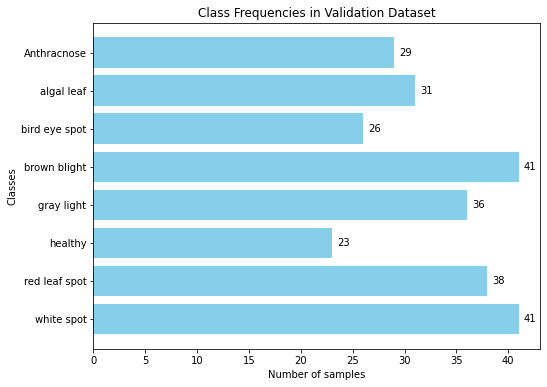

In [12]:
class_names = val_ds.class_names

# Count class frequencies
class_counts = Counter()
for images, labels in val_ds:
    labels = labels.numpy()
    class_counts.update(labels)

counts = [class_counts[i] for i in range(len(class_names))]
labels = class_names

# Create horizontal bar plot
plt.figure(figsize=(8, 6))
bars = plt.barh(labels, counts, color='skyblue')
plt.xlabel("Number of samples")
plt.ylabel("Classes")
plt.title("Class Frequencies in Validation Dataset")
plt.gca().invert_yaxis()

# Add counts on the bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(count), va='center')

plt.show()

In [13]:
num_classes = len(class_names)

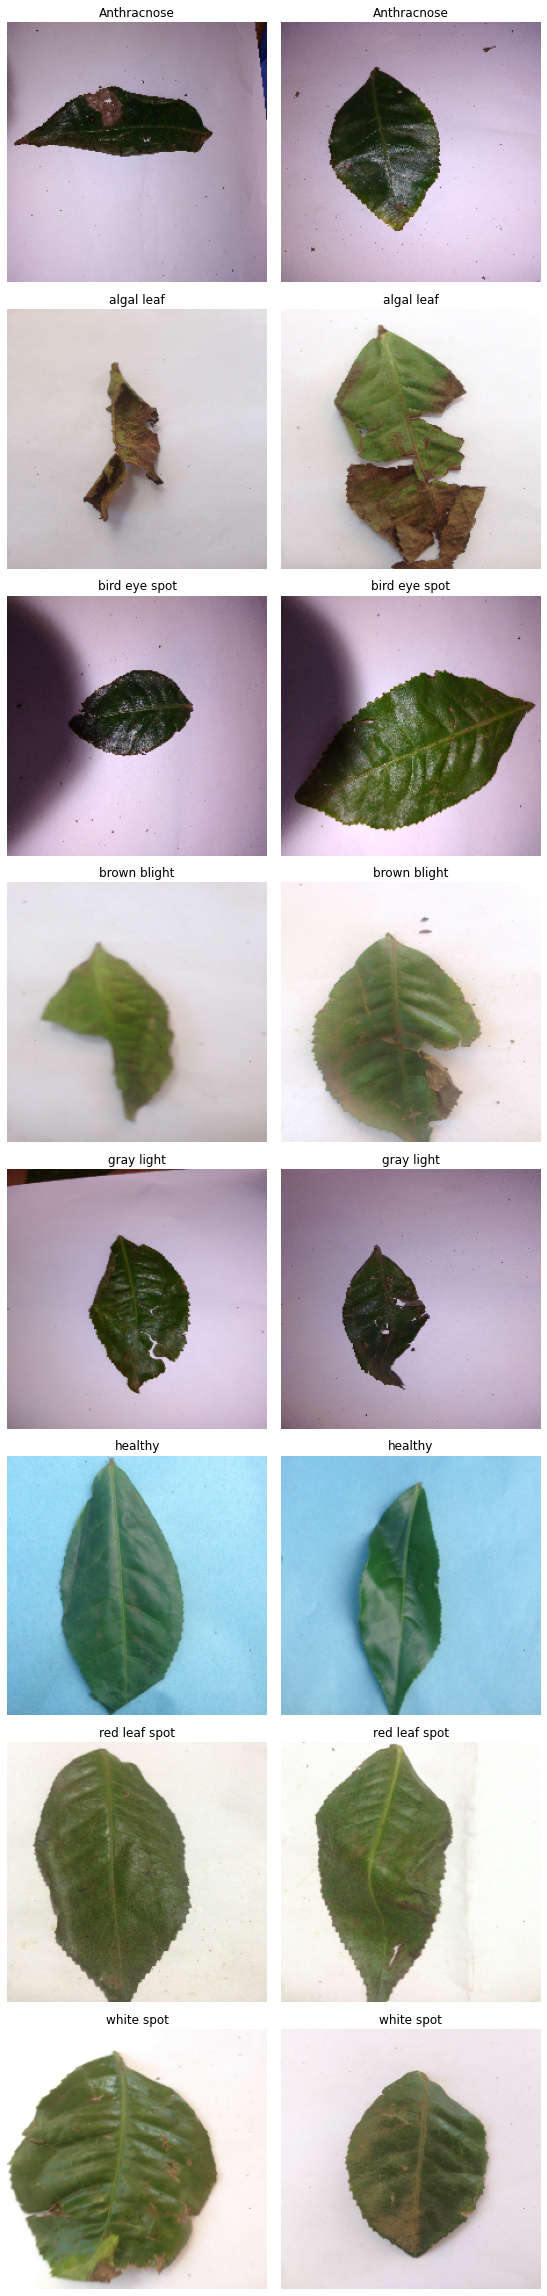

In [14]:
class_names = train_ds.class_names

images_per_class = {class_name: [] for class_name in class_names}

# Loop through dataset batches to collect images
for images, labels in train_ds:
    images = images.numpy()
    labels = labels.numpy()
    for img, lbl in zip(images, labels):
        class_name = class_names[lbl]
        if len(images_per_class[class_name]) < 2:  # collect only 2 per class
            images_per_class[class_name].append(img)
    # Stop early if we have 2 images for every class
    if all(len(v) == 2 for v in images_per_class.values()):
        break

# Plot the images
num_classes = len(class_names)
plt.figure(figsize=(4 * 2, 4 * num_classes))
for i, class_name in enumerate(class_names):
    for j in range(2):
        ax = plt.subplot(num_classes, 2, i*2 + j + 1)
        plt.imshow(images_per_class[class_name][j].astype("uint8"))
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

## **Data Preprocessing**

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## **Build Model**

In [16]:
## Data augmentation layers to increase data variation for training
data_augmentation = Sequential([
    RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    RandomFlip("vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])

In [17]:
model = Sequential([
    data_augmentation,
    
    Rescaling(1./255),

    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, 3, padding='same', activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(256, activation='relu'),
    Dropout(0.3),
    
    BatchNormalization(),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    BatchNormalization(),

    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes)
])

In [18]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (None, 224, 224, 3)       0         
_________________________________________________________________
rescaling (Rescaling)        (None, 224, 224, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 224, 224, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 112, 112, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 56, 56, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 56, 56, 128)      

/opt/conda/lib/python3.7/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


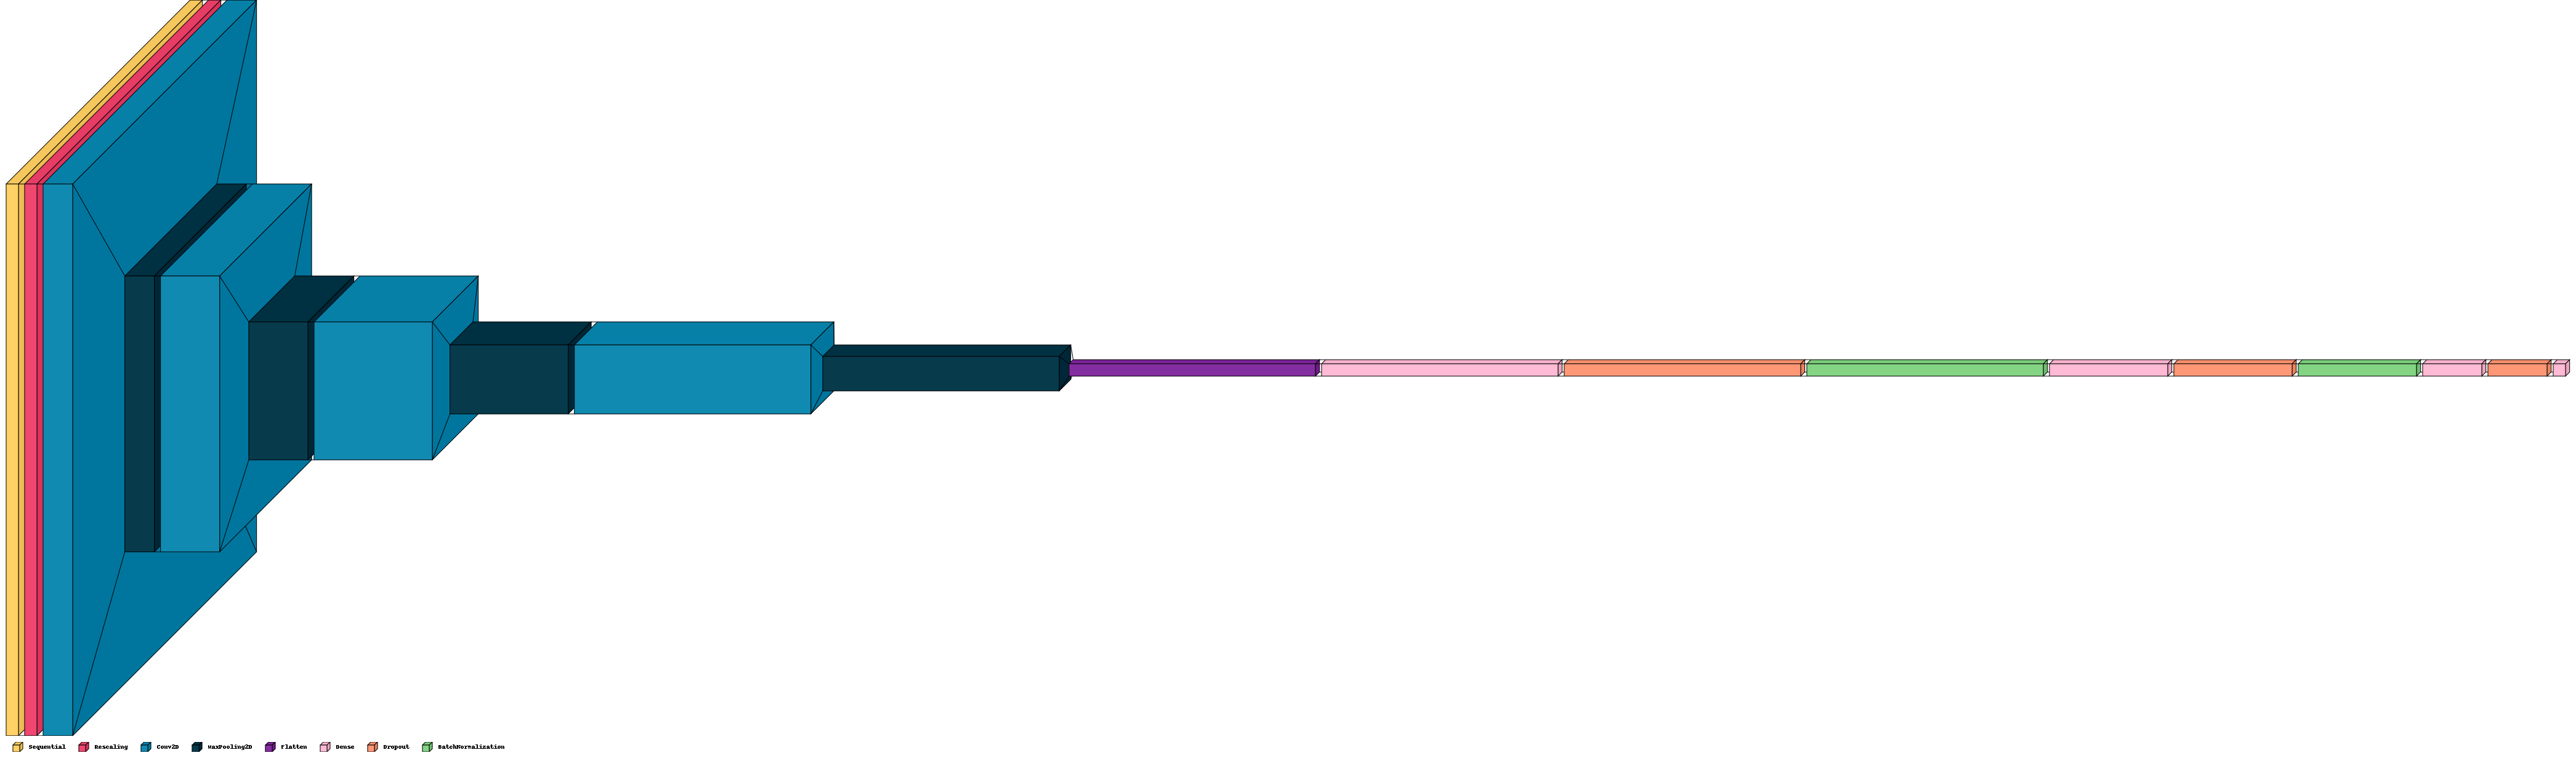

In [19]:
visualkeras.layered_view(model, legend = True)

In [20]:
base_learning_rate = 0.0005

model.compile(optimizer=Adam(learning_rate=base_learning_rate),
              loss=SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
class EarlyStoppingCallback(callbacks.Callback) :
  def on_epoch_end(self, epoch, logs = None) :
    if(logs['val_accuracy'] >= 0.85) :
      self.model.stop_training = True
      print("\nReached 85% validation accuracy, so stopped training !")

## **Train Model**

In [22]:
epochs = 500

history = model.fit(train_ds, 
                    callbacks=[EarlyStoppingCallback()], 
                    validation_data=val_ds,
                    epochs=epochs)

Epoch 1/500
5/5 [==============================] - 25s 1s/step - loss: 2.4999 - accuracy: 0.1306 - val_loss: 2.2605 - val_accuracy: 0.1509
Epoch 2/500
5/5 [==============================] - 1s 142ms/step - loss: 2.4057 - accuracy: 0.1677 - val_loss: 2.2158 - val_accuracy: 0.1434
Epoch 3/500
5/5 [==============================] - 1s 143ms/step - loss: 2.1137 - accuracy: 0.2177 - val_loss: 1.9315 - val_accuracy: 0.2302
Epoch 4/500
5/5 [==============================] - 1s 141ms/step - loss: 1.8881 - accuracy: 0.2694 - val_loss: 1.9915 - val_accuracy: 0.2226
Epoch 5/500
5/5 [==============================] - 1s 142ms/step - loss: 1.7970 - accuracy: 0.2774 - val_loss: 1.7806 - val_accuracy: 0.2415
Epoch 6/500
5/5 [==============================] - 1s 141ms/step - loss: 1.6041 - accuracy: 0.3565 - val_loss: 1.7484 - val_accuracy: 0.4075
Epoch 7/500
5/5 [==============================] - 1s 142ms/step - loss: 1.5226 - accuracy: 0.3919 - val_loss: 1.8977 - val_accuracy: 0.3321
Epoch 8/500
5/5

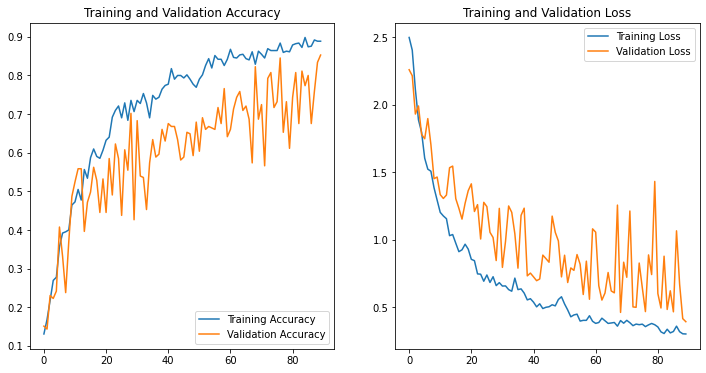

In [23]:
# Check training result
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **Evaluate Model**

In [24]:
all_labels = []
all_predictions = []

for image_batch, label_batch in val_ds:  # iterate over all batches
    preds = model.predict_on_batch(image_batch)
    preds_classes = np.argmax(preds, axis=1)
    
    all_predictions.extend(preds_classes)
    all_labels.extend(label_batch)  # if labels are already integer class indices

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print(classification_report(all_labels, all_predictions, target_names=class_names))

               precision    recall  f1-score   support

  Anthracnose       0.63      0.76      0.69        29
   algal leaf       0.81      0.94      0.87        31
bird eye spot       0.75      0.81      0.78        26
 brown blight       0.95      0.95      0.95        41
   gray light       0.86      0.67      0.75        36
      healthy       1.00      1.00      1.00        23
red leaf spot       1.00      0.89      0.94        38
   white spot       0.85      0.83      0.84        41

     accuracy                           0.85       265
    macro avg       0.86      0.86      0.85       265
 weighted avg       0.86      0.85      0.85       265



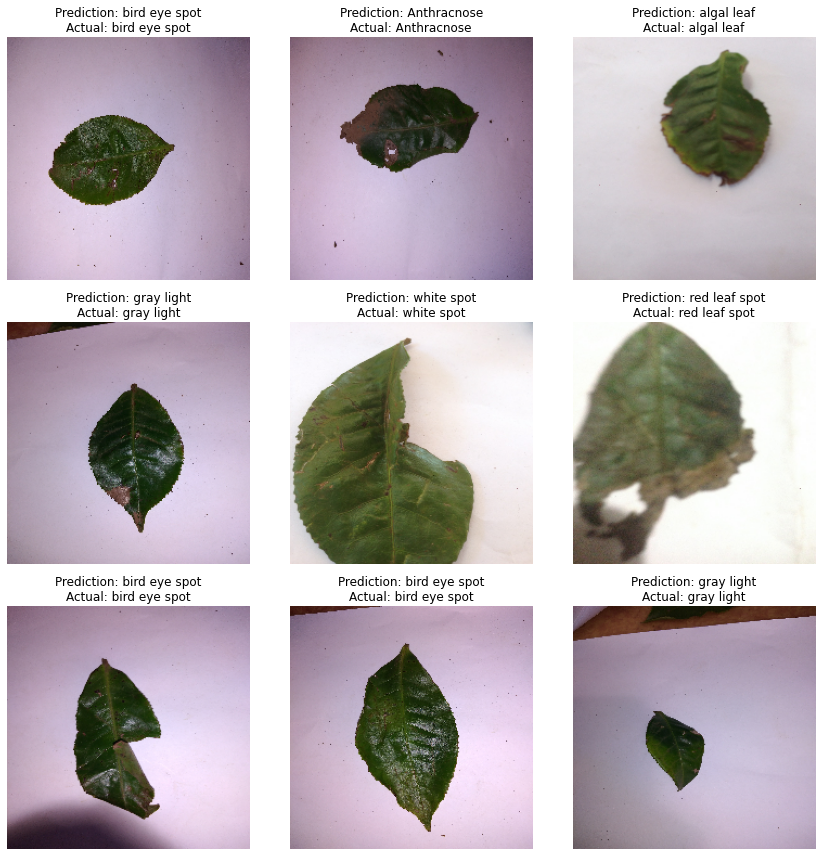

In [25]:
num_images = 9

all_images = []
all_labels = []

for img_batch, label_batch in val_ds:
    all_images.append(img_batch)
    all_labels.append(label_batch)

all_images = np.vstack(all_images)
all_labels = np.hstack(all_labels)

random_indices = random.sample(range(len(all_images)), num_images)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(random_indices):
    img = all_images[idx]
    label = all_labels[idx]

    pred = model.predict(np.expand_dims(img, axis=0))
    pred_class = np.argmax(pred, axis=1)[0]

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"Prediction: {class_names[pred_class]}\nActual: {class_names[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()